In [81]:
import tkinter as tk
from tkinter import filedialog, ttk
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import pandas as pd
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

In [82]:
class Model:
    def __init__(self,x,y,type,N,K,DC):
        mask = x > 0
        self.x = x[mask]
        self.y = y[mask]
        self.type = type
        self._N = N
        self._K = K
        self._DC = DC
    
    @property
    def N(self):
        return self._N
    @property
    def K(self):
        return self._K
    @property
    def DC(self):
        return self._DC
    
    @N.setter
    def N(self, value):
        self._N = value
    
    @K.setter
    def K(self, value):
        self._K = value

    @DC.setter
    def DC(self, value):
        self._DC = value



    def fcs_3D_1p(self,tau, N, tau_D, K, DC):
        return (
            (1 / N)
            * (1 + tau / tau_D)**(-1)
            * (1 + tau / (tau_D * K**2))**(-0.5)
            + DC
        )


    def fcs_3D_2p(self,tau, N, F2, tau_D, tau_D2, K, DC):

        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D)**(-1)
            * (1 + tau / (tau_D * K**2))**(-0.5)
        )

        comp2 = (
            F2
            * (1 + tau / tau_D2)**(-1)
            * (1 + tau / (tau_D2 * K**2))**(-0.5)
        )

        return (1 / N) * (comp1 + comp2) + DC


    def fcs_3D_1p1t(self,tau, N, tau_D, K, F_T, tau_T, DC):

        diffusion = (
            (1 + tau / tau_D)**(-1)
            * (1 + tau / (tau_D * K**2))**(-0.5)
        )

        triplet = (
            1
            + (F_T / (1 - F_T))
            * np.exp(-tau / tau_T)
        )

        return (1 / N) * diffusion * triplet + DC


    def fcs_3D_2p1t(self,tau, N, F2, tau_D, tau_D2, K, F_T, tau_T, DC):

        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D)**(-1)
            * (1 + tau / (tau_D * K**2))**(-0.5)
        )

        comp2 = (
            F2
            * (1 + tau / tau_D2)**(-1)
            * (1 + tau / (tau_D2 * K**2))**(-0.5)
        )

        triplet = (
            1
            + (F_T / (1 - F_T))
            * np.exp(-tau / tau_T)
        )

        return (1 / N) * (comp1 + comp2) * triplet + DC


    # ---------- 2D MODELS ----------

    def fcs_2D_1p(self,tau, N, tau_D, DC):
        return (
            (1 / N)
            * (1 + tau / tau_D)**(-1)
            + DC
        )


    def fcs_2D_2p(self,tau, N, F2, tau_D, tau_D2, DC):

        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D)**(-1)
        )

        comp2 = (
            F2
            * (1 + tau / tau_D2)**(-1)
        )

        return (1 / N) * (comp1 + comp2) + DC


    def fcs_2D_1p1t(self,tau, N, tau_D, F_T, tau_T, DC):

        diffusion = (
            (1 + tau / tau_D)**(-1)
        )

        triplet = (
            1
            + (F_T / (1 - F_T))
            * np.exp(-tau / tau_T)
        )

        return (1 / N) * diffusion * triplet + DC


    def fcs_2D_2p1t(self,tau, N, F2, tau_D, tau_D2, F_T, tau_T, DC):

        comp1 = (
            (1 - F2)
            * (1 + tau / tau_D)**(-1)
        )

        comp2 = (
            F2
            * (1 + tau / tau_D2)**(-1)
        )

        triplet = (
            1
            + (F_T / (1 - F_T))
            * np.exp(-tau / tau_T)
        )

        return (1 / N) * (comp1 + comp2) * triplet + DC
    
    def plot(self, ax_main=None, ax_res=None):
        param_names = {
            "3D_1p":    ["N", "tau_D", "K", "DC"],
            "3D_2p":    ["N", "F2", "tau_D", "tau_D2", "K", "DC"],
            "3D_1p1t":  ["N", "tau_D", "K", "F_T", "tau_T", "DC"],
            "3D_2p1t":  ["N", "F2", "tau_D", "tau_D2", "K", "F_T", "tau_T", "DC"],

            "2D_1p":    ["N", "tau_D", "DC"],
            "2D_2p":    ["N", "F2", "tau_D", "tau_D2", "DC"],
            "2D_1p1t":  ["N", "tau_D", "F_T", "tau_T", "DC"],
            "2D_2p1t":  ["N", "F2", "tau_D", "tau_D2", "F_T", "tau_T", "DC"],
        }
        fixed_values = {}
        all_params = param_names[self.type]
        for p in ["N", "K", "DC"]:
            if p in all_params:
                val = getattr(self,f"_{p}")
                if val is not None:
                    fixed_values[p] = float(val)

        fit_params = [p for p in all_params if p not in fixed_values]

        func = None
        if self.type != None:
            func = getattr(self,f"fcs_{self.type}")

        def wrapper(tau, *free_params):
            param_dict = fixed_values.copy()

            for name, value in zip(fit_params, free_params):
                param_dict[name] = value

            ordered = [param_dict[p] for p in all_params]

            for p in ["N", "K", "DC"]:
                if p in all_params:
                    setattr(self,f"_{p}",param_dict[p])
                else:
                    setattr(self,f"_{p}",None)
                    

            return func(tau, *ordered)

        default_guess = {
            "N": 10,
            "tau_D": 0.1,
            "tau_D2": 1.0,
            "F2": 0.5,
            "K": 5,
            "F_T": 0.1,
            "tau_T": 0.001,
            "DC": 0
        }

        p0 = [default_guess[p] for p in fit_params]

        popt, pcov = curve_fit(
            wrapper,
            self.x,
            self.y,
            p0=p0,
            maxfev=20000
        )

        if ax_main is None or ax_res is None:
            fig, (ax_main, ax_res) = plt.subplots(2, 1, sharex=True)
            
        ax_main.set_xscale("log")
        ax_res.set_xscale("log")
        x_fit = np.logspace(np.log10(self.x.min()), np.log10(self.x.max()), 1000)
        y_fit = wrapper(x_fit, *popt)
        ax_main.scatter(self.x, self.y, s=10, color='blue', alpha=0.6, label='Experimental Data')
        ax_main.plot(self.x, self.y, label='Experimental graph')
        ax_main.plot(x_fit, y_fit, 'r-', label='3D Fit')
        y_pred = wrapper(self.x, *popt)
        residuals = self.y - y_pred
        ax_res.plot(self.x, residuals)
        ax_main.legend()


    
        


In [83]:
class DataAnalysisApp:
    def __init__(self, root):
        self.root = root
        self.root.title("FCS FITTING APP")
        self.root.geometry("1200x700")

        self.df = None
        self.loaded_files = []

        # parameters
        self.K = None
        self.N = None
        self.DC = None

        self.setup_ui()

    # ================= UI =================
    def setup_ui(self):

        # -------- SIDEBARS --------
        self.sidebar = tk.Frame(self.root, width=250, bg="#f0f0f0",
                                relief="sunken", borderwidth=1)
        self.sidebar.pack(side="left", fill="y")

        self.sidebar2 = tk.Frame(self.root, width=250, bg="#f0f0f0",
                                 relief="sunken", borderwidth=1)
        self.sidebar2.pack(side="right", fill="y")

        self.main_content = tk.Frame(self.root, bg="white")
        self.main_content.pack(side="right", expand=True, fill="both")

        # -------- FILES --------
        tk.Label(self.sidebar, text="File Explorer",
                 font=("Arial", 12, "bold"), bg="#f0f0f0").pack(pady=10)

        btn_frame = tk.Frame(self.sidebar, bg="#f0f0f0")
        btn_frame.pack(fill="x", padx=5)

        tk.Button(btn_frame, text="Load Files",
                  command=self.load_files).pack(side="left", fill="x", expand=True)

        tk.Button(btn_frame, text="Load Folder",
                  command=self.load_folder).pack(side="left", fill="x", expand=True)

        self.file_listbox = tk.Listbox(self.sidebar)
        self.file_listbox.pack(expand=True, fill="both", padx=5, pady=5)
        self.file_listbox.bind("<<ListboxSelect>>", self.on_file_select)

        # -------- CONTROLS --------
        self.controls = tk.Frame(self.main_content, height=80,
                                 relief="raised", borderwidth=1)
        self.controls.pack(fill="x")

        tk.Label(self.controls, text="Model:").grid(row=0, column=0)

        self.fit_style = ttk.Combobox(
            self.controls,
            values=["3D_1p","3D_2p","3D_1p1t","3D_2p1t",
                    "2D_1p","2D_2p","2D_1p1t","2D_2p1t"]
        )
        self.fit_style.set("3D_1p")
        self.fit_style.grid(row=0, column=1)

        tk.Button(self.controls, text="Update Fit",
                  command=self.update_graphs).grid(row=0, column=2, padx=10)

        # -------- PARAM SIDEBAR --------
        tk.Label(self.sidebar2, text="Parameters",
                 font=("Arial", 12, "bold"),
                 bg="#f0f0f0").pack(pady=10)

        # lock toggle
        self.lock_params = tk.BooleanVar(value=False)

        # input frame
        param_frame = tk.Frame(self.sidebar2, bg="#f0f0f0")
        param_frame.pack(pady=10)

        tk.Label(param_frame, text="K:").grid(row=0, column=0)
        self.k_entry = tk.Entry(param_frame)
        self.k_entry.grid(row=0, column=1)

        tk.Label(param_frame, text="N:").grid(row=1, column=0)
        self.n_entry = tk.Entry(param_frame)
        self.n_entry.grid(row=1, column=1)

        tk.Label(param_frame, text="DC:").grid(row=2, column=0)
        self.dc_entry = tk.Entry(param_frame)
        self.dc_entry.grid(row=2, column=1)

        # results display
        tk.Label(self.sidebar2, text="Fit Results",
                 font=("Arial", 11, "bold"),
                 bg="#f0f0f0").pack(pady=10)

        self.result_label = tk.Label(
            self.sidebar2,
            text="N = -\nK = -\nDC = -",
            justify="left",
            bg="#f0f0f0"
        )
        self.result_label.pack()

        # -------- PLOTS --------
        self.fig = plt.figure(figsize=(10, 6), constrained_layout=True)
        gs = self.fig.add_gridspec(2, 2)

        self.ax_main = self.fig.add_subplot(gs[0, :])
        self.ax_int = self.fig.add_subplot(gs[1, 0])
        self.ax_res = self.fig.add_subplot(gs[1, 1])

        self.canvas = FigureCanvasTkAgg(self.fig, master=self.main_content)
        self.canvas.get_tk_widget().pack(expand=True, fill="both")

    # ================= PARAMS =================
    def get_params(self):
        def parse(entry):
            v = entry.get().strip()
            return float(v) if v != "" else None

        if self.lock_params.get():
            return (
                parse(self.k_entry),
                parse(self.n_entry),
                parse(self.dc_entry)
            )
        return (None, None, None)

    # ================= FILES =================
    def load_files(self):
        files = filedialog.askopenfilenames(
            filetypes=[("Data", "*.dat *.czi *.ptu")]
        )
        for f in files:
            if f not in self.loaded_files:
                self.loaded_files.append(f)
                self.file_listbox.insert(tk.END, f.split("/")[-1])

    def load_folder(self):
        folder = filedialog.askdirectory()
        import os
        for r, _, fs in os.walk(folder):
            for f in fs:
                if f.endswith((".dat", ".czi", ".ptu")):
                    full = os.path.join(r, f)
                    if full not in self.loaded_files:
                        self.loaded_files.append(full)
                        self.file_listbox.insert(tk.END, f)

    def dat_to_df(self, path):
        return pd.read_csv(path, sep=r"\s+", skiprows=1)

    def on_file_select(self, event):
        i = event.widget.curselection()[0]
        self.df = self.dat_to_df(self.loaded_files[i])
        self.update_graphs()

    # ================= PLOT =================
    def update_graphs(self):
        if self.df is None:
            return

        # 🚨 AUTO-LOCK ON UPDATE
        self.lock_params.set(True)

        x = self.df.iloc[:, 0]
        y = self.df.iloc[:, 1]

        self.ax_main.clear()
        self.ax_int.clear()
        self.ax_res.clear()

        K, N, DC = self.get_params()

        model = Model(x, y,
                      self.fit_style.get(),
                      N, K, DC)

        model.plot(ax_main=self.ax_main, ax_res=self.ax_res)
        self.ax_int.plot(x, y)

        # ONLY MODEL NAME IN TITLE
        self.ax_main.set_title(self.fit_style.get())
        self.ax_int.set_title("Intensity Trace")
        self.ax_res.set_title("Residuals")

        # UPDATE SIDEBAR RESULTS
        def fmt(v):
            return "auto" if v is None else f"{v:.4g}"

        self.result_label.config(
            text=f"N = {fmt(model.N)}\nK = {fmt(model.K)}\nDC = {fmt(model.DC)}"
        )

        self.canvas.draw()

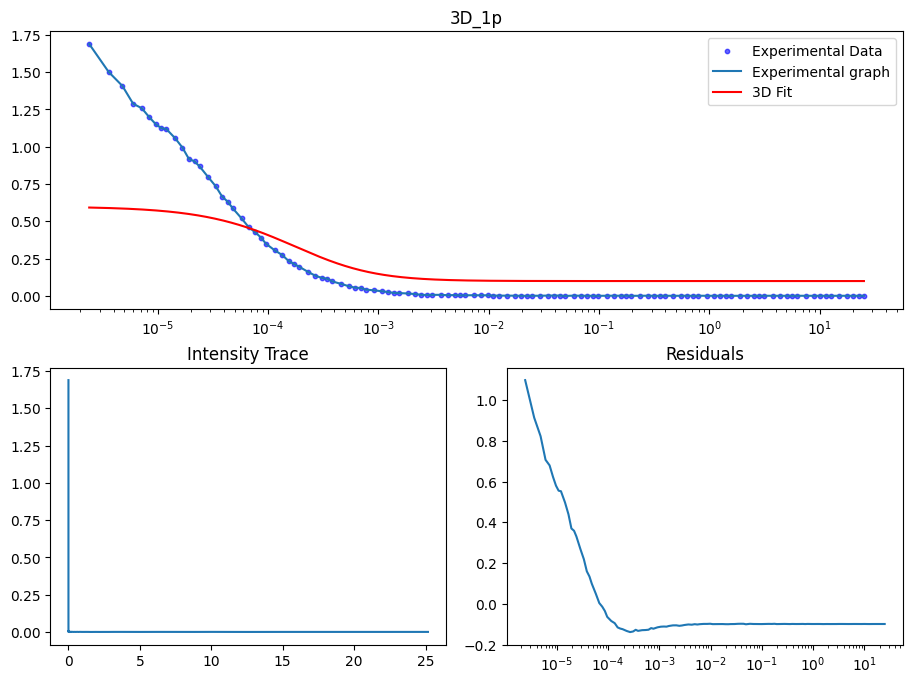

In [84]:
root = tk.Tk()
app = DataAnalysisApp(root)
root.mainloop()